# Kalshi & Polymarket Event Study Data Extraction

**Source:** J. Becker  
**Purpose:** Extract market snapshots and trade histories for event study analysis across Kalshi (binary prediction market) and Polymarket (AMM-based market) platforms.

## Overview

This notebook:
1. Downloads compressed archival data (trades, blocks, market snapshots from 2023–2026)
2. Identifies markets active around key event dates (e.g., Ukraine-Russia news, Zelensky lawsuit resolution)
3. Extracts **price snapshots** at 5 am and 5 pm PT on each day in a rolling window
4. Produces both **long-format audit tables** (one row per market-time pair) and **wide-format tables** (one row per market with time-series prices as columns)
5. Generates reference data dictionaries describing column metadata

## Data Caveat

All market snapshots in the archive are **ex-post** (fetched in late February 2026), not collected in real-time during the event windows. Volume/liquidity figures represent full-history values, not contemporaneous measures during the event period. These are a **first-pass approximation** of market activity and interest.

In [ ]:
# =========================================================================
# SECTION: Data Download & Extraction
# =========================================================================
from data_downloader import download_and_extract_data

URL = "https://s3.jbecker.dev/data.tar.zst"
ARCHIVE_NAME = "data.tar.zst"
OUTPUT_DIR = "."

# Call the function to download and extract data
download_and_extract_data(URL, ARCHIVE_NAME, OUTPUT_DIR)

In [ ]:
# =========================================================================
# SECTION: Data Integrity Check & Clean Extraction (Alternative)
# =========================================================================
from data_downloader import verify_and_clean_extraction

URL = "https://s3.jbecker.dev/data.tar.zst"
ARCHIVE_NAME = "data.tar.zst"
OUTPUT_DIR = "."
FORCE_CLEAN = False

# Call the function to verify and clean extraction
verify_and_clean_extraction(URL, ARCHIVE_NAME, OUTPUT_DIR, force_clean=FORCE_CLEAN)

remote_size = 36,020,641,508
local_size  = 36,020,641,508
Done.


## Event Studies: Price Snapshots Around Known Dates

For each event study, we:
1. **Define a time window**: 1 week before the event through 1 week after
2. **Build daily cutoffs**: 5 am and 5 pm Pacific Time in the window
3. **Pull trades**: For each market, find the most recent trade price at each cutoff time using `merge_asof` (backward/"as-of" snapshot logic)
4. **Output formats**:
   - **Snapshots (long)**: One row per (market, cutoff_time), shows the trade timestamp and price nearest to that cutoff
   - **Wide**: One row per market, with columns for each cutoff's price (easier for cross-market time-series analysis)
5. **Parallel extraction**: Top-100 markets (by volume proxy) and topic-filtered markets (Ukraine-related keywords)

**Time zone note**: All cutoffs are computed in Pacific Time (`America/Los_Angeles`), then converted to UTC for trade queries.

## Topic-Filtered Markets: Ukraine-Russia Events

Rather than using full-period top-100 rankings, this section filters for markets explicitly related to Ukraine, Russia, and regional geopolitics. Using a regex search across market titles/descriptions, we extract:
- Markets that match topic keywords (ukraine, russia, putin, nato, etc.)
- Trade history and price snapshots during the same event window (5 am/5 pm PT)

**Note:** Different markets may have different trading patterns and activity levels during the event period compared to the aggregated top-100 set.

In [2]:
from data_processing import extract_event_study

# Topic regex pattern for Ukraine-Russia events
TOPIC_PATTERNS = [
    r"\bukraine\b",
    r"\bukrainian\b",
    r"\brussia\b",
    r"\brussian\b",
    r"\bputin\b",
    r"\bzelensky\b",
    r"\bzelenskyy\b",
    r"\bzelenskyyy\b",
    r"\bzelenskyj\b",
    r"\bkyiv\b",
    r"\bkiev\b",
    r"\bmoscow\b",
    r"\bkremlin\b",
    r"\bdonbas\b",
    r"\bdonetsk\b",
    r"\bluhansk\b",
    r"\bcrimea\b",
    r"\bsevastopol\b",
    r"\bkharkiv\b",
    r"\bodesa\b",
    r"\bodessa\b",
    r"\bzaporizhzhia\b",
    r"\bzaporizhia\b",
    r"\bkherson\b",
    r"\bmariupol\b",
    r"\bnato\b",
]

TOPIC_REGEX = "|".join(TOPIC_PATTERNS)

# Extract event study for March 24, 2025 event
extract_event_study(
    event_start_date="2025-03-24",
    event_end_date="2025-03-24",
    window_days=7,
    topic_regex=TOPIC_REGEX,
    slug="mineral_rights"
)


=== Event Study: MINERAL_RIGHTS ===
Event window: 2025-03-24 to 2025-03-24
Analysis window: 2025-03-17 to 2025-03-31
Final cutoff UTC: 2025-04-01 00:00:00

Polymarket topic markets: 79 -> exports\mineral_rights_pm_topics.csv
Kalshi topic markets: 19 -> exports\mineral_rights_k_topics.csv
Kalshi trades pulled: 14,984
Kalshi long  -> exports\mineral_rights_k_long.csv
Kalshi wide  -> exports\mineral_rights_k_wide.csv
Polymarket trades pulled: 1,035,019
Polymarket long  -> exports\mineral_rights_pm_long.csv
Polymarket wide  -> exports\mineral_rights_pm_wide.csv

Done.



## Zelensky-Suit Event Study

This section repeats the earlier extraction workflow for a different event: the Zelensky lawsuit market resolution window. Since that market took multiple days to resolve, we specify both a **resolution start date** and **resolution end date**, then extract price history from one week before the start through one week after the end.

The workflow mirrors the March 24 event study:
- Top-100 markets by volume active during the window
- Topic-filtered (Ukraine-related) markets
- Price snapshots at 5 am and 5 pm PT each day
- Both long (audit) and wide (time-series) CSV outputs

In [ ]:
from data_processing import extract_event_study

# Topic regex pattern for Ukraine-Russia events
TOPIC_PATTERNS = [
    r"\bukraine\b",
    r"\bukrainian\b",
    r"\brussia\b",
    r"\brussian\b",
    r"\bputin\b",
    r"\bzelensky\b",
    r"\bzelenskyy\b",
    r"\bzelenskyyy\b",
    r"\bzelenskyj\b",
    r"\bkyiv\b",
    r"\bkiev\b",
    r"\bmoscow\b",
    r"\bkremlin\b",
    r"\bdonbas\b",
    r"\bdonetsk\b",
    r"\bluhansk\b",
    r"\bcrimea\b",
    r"\bsevastopol\b",
    r"\bkharkiv\b",
    r"\bodesa\b",
    r"\bodessa\b",
    r"\bzaporizhzhia\b",
    r"\bzaporizhia\b",
    r"\bkherson\b",
    r"\bmariupol\b",
    r"\bnato\b",
]

TOPIC_REGEX = "|".join(TOPIC_PATTERNS)

# Extract event study for March 24, 2025 event
extract_event_study(
    event_start_date="2025-06-30",
    event_end_date="2025-07-08",
    window_days=7,
    topic_regex=TOPIC_REGEX,
    slug="zelensky_suit"
)



=== Event Study: ZELENSKY_SUIT ===
Event window: 2025-06-30 to 2025-07-08
Analysis window: 2025-06-23 to 2025-07-15
Final cutoff UTC: 2025-07-16 00:00:00

Polymarket topic markets: 52 -> exports\zelensky_suit_pm_topics.csv
Kalshi topic markets: 26 -> exports\zelensky_suit_k_topics.csv
Kalshi trades pulled: 11,798
Kalshi long  -> exports\zelensky_suit_k_long.csv
Kalshi wide  -> exports\zelensky_suit_k_wide.csv
Polymarket trades pulled: 169,120
Polymarket long  -> exports\zelensky_suit_pm_long.csv
Polymarket wide  -> exports\zelensky_suit_pm_wide.csv

Done.



## Favored Position Price Visualization

This section visualizes the price levels of the favored position (>50c pre-event) over time across markets. We aggregate prices separately for each event/slug and platform (Kalshi/Polymarket), showing mean and median with standard deviation fill, and vertical lines for event dates.

In [6]:
# =========================================================================
# SECTION: Favored Position Price Visualization
# =========================================================================
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
from datetime import datetime

In [7]:
def load_and_process_wide_file(file_path, event_date=None):
    df = pd.read_csv(file_path)
    
    # Identify time columns and extract date info
    if '_k_wide' in file_path:
        time_cols = [col for col in df.columns if col.startswith('yes_') and ('open_0500_PT' in col or 'close_1700_PT' in col)]
        prefix = 'yes_'
    else:  # polymarket
        time_cols = [col for col in df.columns if col.startswith('outcome_') and ('open_0500_PT' in col or 'close_1700_PT' in col)]
        prefix = 'outcome_'
    
    # Extract unique date-time tuples
    dates = set()
    for col in time_cols:
        match = re.search(r'(\d{4})_(\d{2})_(\d{2})_(open_0500_PT|close_1700_PT)', col)
        if match:
            dates.add((match.group(1), match.group(2), match.group(3), match.group(4)))
    
    sorted_dates = sorted(dates, key=lambda x: (x[0], x[1], x[2], 0 if x[3] == 'open_0500_PT' else 1))
    
    if not sorted_dates:
        raise ValueError("No time columns found")
    
    # Determine pre-event baseline: last price BEFORE event_date
    if event_date:
        # Parse event_date (e.g., "2025-03-24")
        event_year, event_month, event_day = event_date.split('-')
        # Filter to dates strictly before event_date
        pre_event_dates = [d for d in sorted_dates if (d[0], d[1], d[2]) < (event_year, event_month, event_day)]
        pre_event = pre_event_dates[-1] if pre_event_dates else sorted_dates[0]
    else:
        # Fallback: use first date if no event_date provided
        pre_event = sorted_dates[0]
    
    # For each market, determine favored position
    favored_prices = []
    for idx, row in df.iterrows():
        if '_k_wide' in file_path:
            pre_col = f'yes_{pre_event[0]}_{pre_event[1]}_{pre_event[2]}_{pre_event[3]}'
            if pre_col not in df.columns or pd.isna(row[pre_col]):
                continue
            if row[pre_col] > 0.5:
                # Track YES
                prices = [row[f'yes_{d[0]}_{d[1]}_{d[2]}_{d[3]}'] for d in sorted_dates]
            else:
                # Track NO (1 - YES)
                prices = [1 - row[f'yes_{d[0]}_{d[1]}_{d[2]}_{d[3]}'] if not pd.isna(row[f'yes_{d[0]}_{d[1]}_{d[2]}_{d[3]}']) else pd.NA for d in sorted_dates]
        else:  # polymarket
            pre_suffix = f'_{pre_event[0]}_{pre_event[1]}_{pre_event[2]}_{pre_event[3]}'
            pre_col_0_candidates = [col for col in df.columns if col.startswith('outcome_0_') and col.endswith(pre_suffix)]
            pre_col_1_candidates = [col for col in df.columns if col.startswith('outcome_1_') and col.endswith(pre_suffix)]
            pre_col_0 = pre_col_0_candidates[0] if pre_col_0_candidates else None
            pre_col_1 = pre_col_1_candidates[0] if pre_col_1_candidates else None
            favored = None
            if pre_col_0 and not pd.isna(row[pre_col_0]) and row[pre_col_0] > 0.5:
                favored = 0
            elif pre_col_1 and not pd.isna(row[pre_col_1]) and row[pre_col_1] > 0.5:
                favored = 1
            if favored is None:
                continue
            prices = []
            for d in sorted_dates:
                suffix = f'_{d[0]}_{d[1]}_{d[2]}_{d[3]}'
                col_candidates = [col for col in df.columns if col.startswith(f'outcome_{favored}_') and col.endswith(suffix)]
                col = col_candidates[0] if col_candidates else None
                prices.append(row[col] if col and col in df.columns else pd.NA)
        
        favored_prices.append(prices)
    
    # Create DataFrame with time columns
    if favored_prices:
        time_labels = [f'{d[0]}_{d[1]}_{d[2]}_{d[3]}' for d in sorted_dates]
        result_df = pd.DataFrame(favored_prices, columns=time_labels)
        return result_df, sorted_dates
    else:
        return pd.DataFrame(), []

In [8]:
def aggregate_favored_prices(df):
    if df.empty:
        return pd.DataFrame()
    
    agg = df.agg(['mean', 'median', 'std']).T
    agg.index.name = 'time'
    agg.reset_index(inplace=True)
    return agg

In [9]:
def plot_favored_aggregates(agg_df, sorted_dates, event_dates, slug, platform):
    if agg_df.empty:
        print(f"No data for {slug} {platform}")
        return
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Create times for x-axis
    times = [datetime(int(d[0]), int(d[1]), int(d[2]), 5 if d[3] == 'open_0500_PT' else 17) for d in sorted_dates]
    
    # Plot mean with SD fill
    mean_vals = agg_df['mean']
    std_vals = agg_df['std']
    ax.fill_between(times, mean_vals - std_vals, mean_vals + std_vals, alpha=0.3, color='blue', label='Mean ± SD')
    ax.plot(times, mean_vals, color='blue', linewidth=2, label='Mean')
    
    # Plot median
    ax.plot(times, agg_df['median'], color='red', linewidth=2, linestyle='--', label='Median')
    
    # Vertical lines for events
    for event_date in event_dates:
        if isinstance(event_date, str):
            event_dt = datetime.fromisoformat(event_date)
        else:
            event_dt = event_date
        ax.axvline(event_dt, color='black', linestyle=':', linewidth=2, label=f'Event: {event_date}')
    
    ax.set_xlabel('Time')
    ax.set_ylabel('Favored Position Price')
    ax.set_title(f'Favored Position Prices: {slug} ({platform})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'exports/{slug}_{platform}_favored_prices.png', dpi=150)
    plt.show()

In [16]:
def load_and_process_wide_file_strict(file_path, event_date=None):
    """Requires ALL pre-event prices to be > 0.5 for market inclusion"""
    df = pd.read_csv(file_path)
    
    # Identify time columns and extract date info
    if '_k_wide' in file_path:
        time_cols = [col for col in df.columns if col.startswith('yes_') and ('open_0500_PT' in col or 'close_1700_PT' in col)]
        prefix = 'yes_'
    else:  # polymarket
        time_cols = [col for col in df.columns if col.startswith('outcome_') and ('open_0500_PT' in col or 'close_1700_PT' in col)]
        prefix = 'outcome_'
    
    # Extract unique date-time tuples
    dates = set()
    for col in time_cols:
        match = re.search(r'(\d{4})_(\d{2})_(\d{2})_(open_0500_PT|close_1700_PT)', col)
        if match:
            dates.add((match.group(1), match.group(2), match.group(3), match.group(4)))
    
    sorted_dates = sorted(dates, key=lambda x: (x[0], x[1], x[2], 0 if x[3] == 'open_0500_PT' else 1))
    
    if not sorted_dates:
        raise ValueError("No time columns found")
    
    # Determine pre-event period
    if event_date:
        event_year, event_month, event_day = event_date.split('-')
        pre_event_dates = [d for d in sorted_dates if (d[0], d[1], d[2]) < (event_year, event_month, event_day)]
    else:
        pre_event_dates = sorted_dates
    
    if not pre_event_dates:
        return pd.DataFrame(), []
    
    # For each market, check if ALL pre-event prices are > 0.5
    favored_prices = []
    for idx, row in df.iterrows():
        if '_k_wide' in file_path:
            # Check all pre-event YES prices
            pre_prices = []
            for d in pre_event_dates:
                col = f'yes_{d[0]}_{d[1]}_{d[2]}_{d[3]}'
                if col in df.columns and not pd.isna(row[col]):
                    pre_prices.append(row[col])
                else:
                    break  # Skip market if any pre-event price is missing
            
            if not pre_prices or len(pre_prices) < len(pre_event_dates):
                continue  # Skip if missing pre-event data
            
            # Check if ALL pre-event prices are > 0.5
            if all(p > 0.5 for p in pre_prices):
                # Track YES prices through full period
                prices = [row[f'yes_{d[0]}_{d[1]}_{d[2]}_{d[3]}'] for d in sorted_dates]
            elif all(p < 0.5 for p in pre_prices):
                # Track NO prices (1 - YES) through full period
                prices = [1 - row[f'yes_{d[0]}_{d[1]}_{d[2]}_{d[3]}'] if not pd.isna(row[f'yes_{d[0]}_{d[1]}_{d[2]}_{d[3]}']) else pd.NA for d in sorted_dates]
            else:
                # Mixed: skip market
                continue
        else:  # polymarket
            # Find outcome columns with valid data for each pre-event date
            pre_prices_0 = []
            pre_prices_1 = []
            col_0_base = None
            col_1_base = None
            
            for d in pre_event_dates:
                suffix = f'_{d[0]}_{d[1]}_{d[2]}_{d[3]}'
                col_0_candidates = [col for col in df.columns if col.startswith('outcome_0_') and col.endswith(suffix)]
                col_1_candidates = [col for col in df.columns if col.startswith('outcome_1_') and col.endswith(suffix)]
                
                # Find first outcome_0 with data
                col_0 = None
                for c0 in col_0_candidates:
                    if pd.notna(row[c0]):
                        col_0 = c0
                        break
                
                # Find first outcome_1 with data
                col_1 = None
                for c1 in col_1_candidates:
                    if pd.notna(row[c1]):
                        col_1 = c1
                        break
                
                if col_0 is None or col_1 is None:
                    break  # Skip if missing data
                
                pre_prices_0.append(row[col_0])
                pre_prices_1.append(row[col_1])
                
                # Extract base labels for consistent tracking
                if col_0_base is None:
                    col_0_base = col_0.replace(suffix, '').replace('outcome_0_', '')
                    col_1_base = col_1.replace(suffix, '').replace('outcome_1_', '')
            
            if len(pre_prices_0) < len(pre_event_dates):
                continue  # Skip if missing pre-event data
            
            # Determine favored outcome: all pre-event prices must be > 0.5 for one outcome
            if all(p > 0.5 for p in pre_prices_0):
                favored = 0
                base_col = col_0_base
            elif all(p > 0.5 for p in pre_prices_1):
                favored = 1
                base_col = col_1_base
            else:
                continue  # Skip: no consistent favored outcome
            
            # Track favored outcome through full period
            prices = []
            for d in sorted_dates:
                suffix = f'_{d[0]}_{d[1]}_{d[2]}_{d[3]}'
                col = f'outcome_{favored}_{base_col}{suffix}'
                prices.append(row[col] if col in df.columns and pd.notna(row[col]) else pd.NA)
        
        favored_prices.append(prices)
    
    # Create DataFrame with time columns
    if favored_prices:
        time_labels = [f'{d[0]}_{d[1]}_{d[2]}_{d[3]}' for d in sorted_dates]
        result_df = pd.DataFrame(favored_prices, columns=time_labels)
        return result_df, sorted_dates
    else:
        return pd.DataFrame(), []

Processing exports\mineral_rights_k_wide.csv


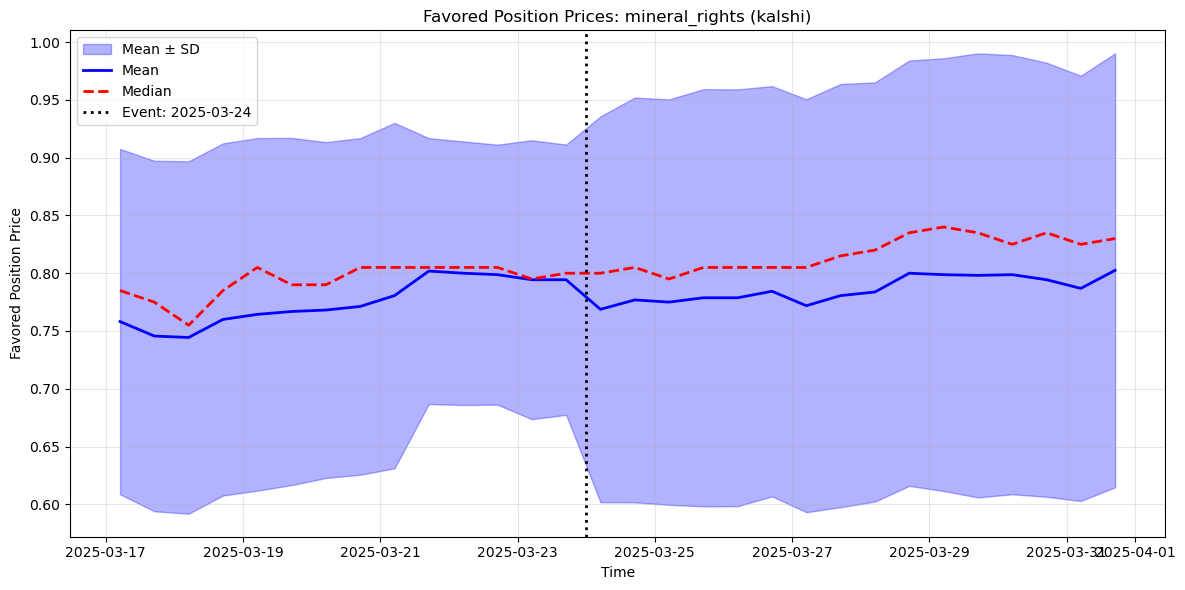

Processing exports\mineral_rights_pm_wide.csv


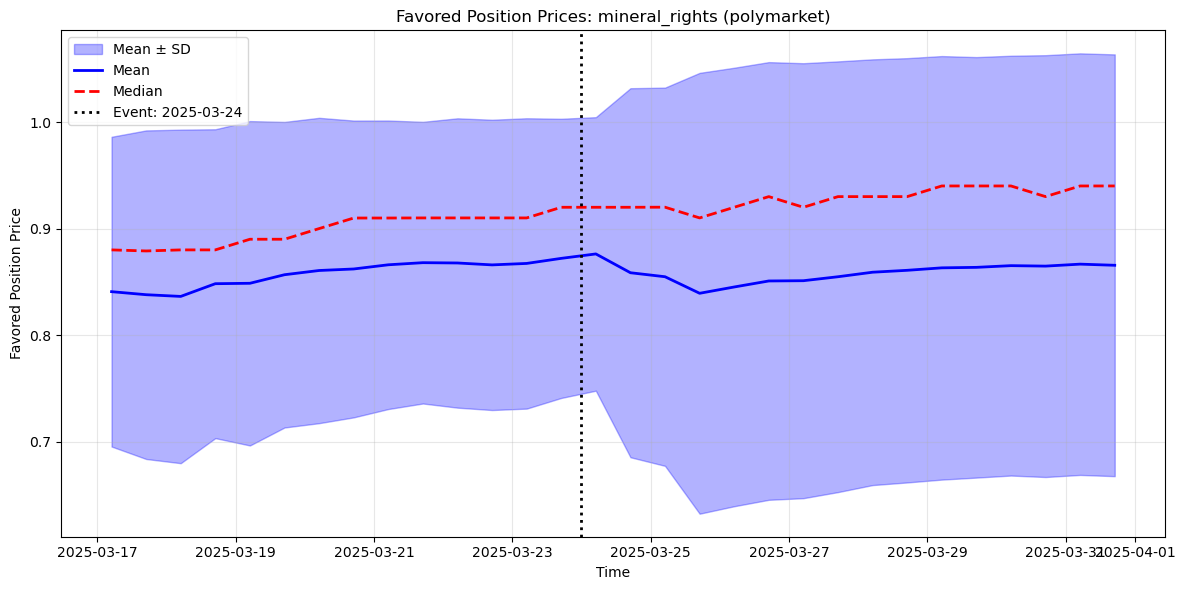

Processing exports\zelensky_suit_k_wide.csv


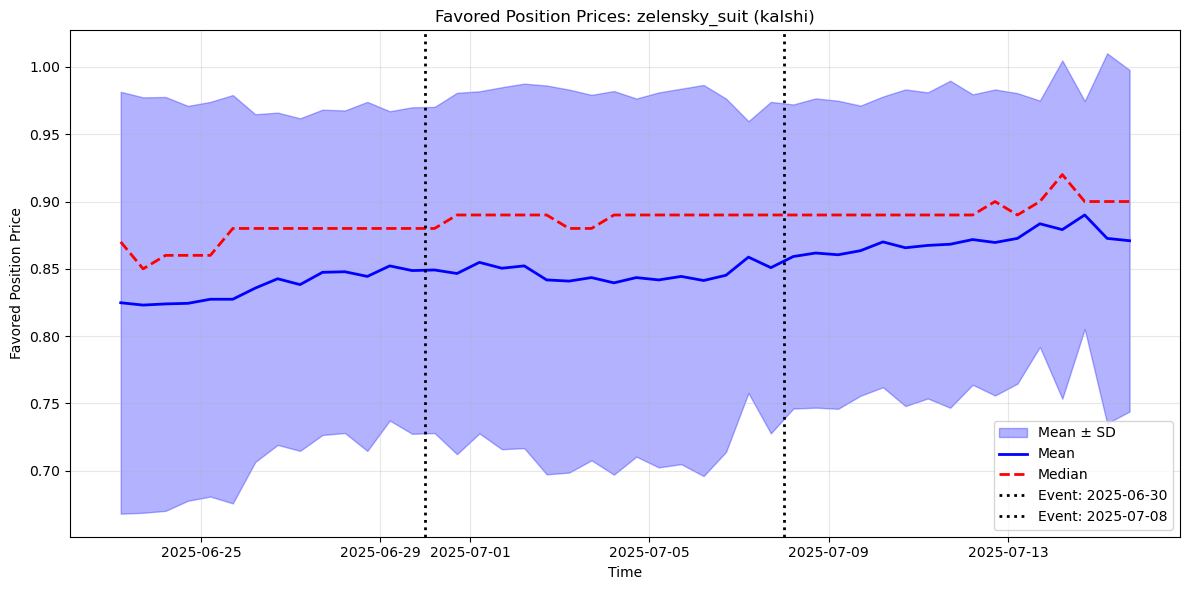

Processing exports\zelensky_suit_pm_wide.csv


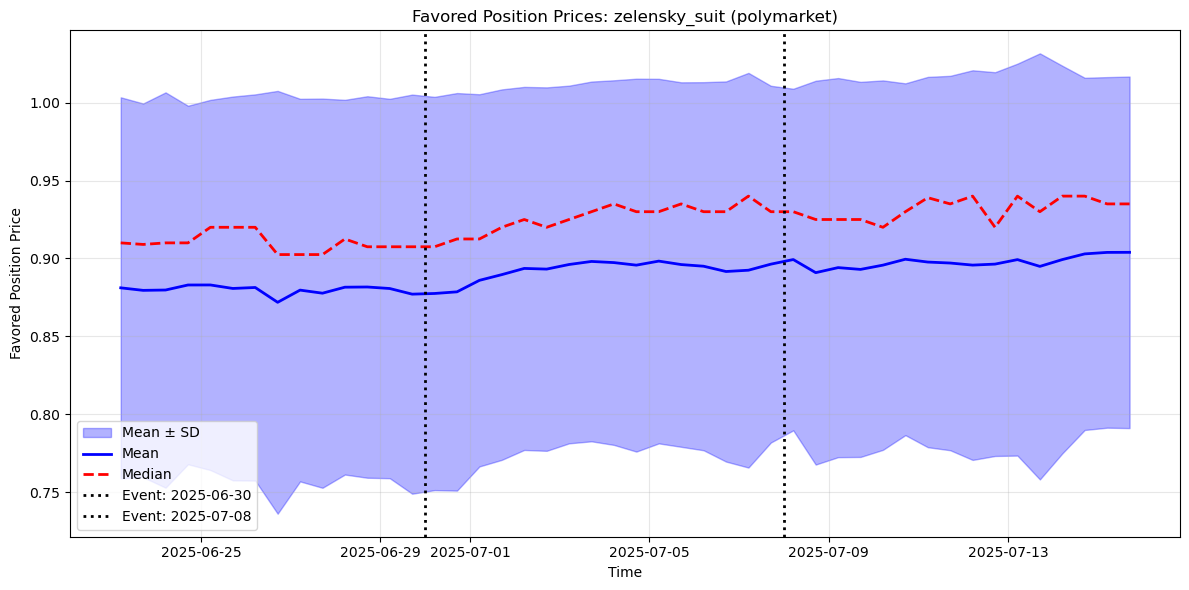

In [11]:
# Define files and event dates by searching exports directory
import glob

wide_files = glob.glob('exports/*_wide.csv')

files_and_events = {}
for file_path in wide_files:
    filename = os.path.basename(file_path)
    if '_k_wide' in filename:
        platform = 'kalshi'
        slug = filename.split('_k_wide')[0]
    elif '_pm_wide' in filename:
        platform = 'polymarket'
        slug = filename.split('_pm_wide')[0]
    else:
        continue
    
    # Event dates
    if slug == 'zelensky_suit':
        event_dates = ['2025-06-30', '2025-07-08']
    else:
        event_dates = ['2025-03-24']
    
    if slug not in files_and_events:
        files_and_events[slug] = {'event_dates': event_dates, 'files': []}
    files_and_events[slug]['files'].append(file_path)

# Process each slug
for slug, config in files_and_events.items():
    for file_path in config['files']:
        if os.path.exists(file_path):
            print(f"Processing {file_path}")
            try:
                # Use first event date as the baseline for favored position
                event_date = config['event_dates'][0]
                df, sorted_dates = load_and_process_wide_file(file_path, event_date=event_date)
                agg_df = aggregate_favored_prices(df)
                platform = 'kalshi' if '_k_wide' in file_path else 'polymarket'
                plot_favored_aggregates(agg_df, sorted_dates, config['event_dates'], slug, platform)
            except Exception as e:
                print(f"Error processing {file_path}: {e}")
        else:
            print(f"File not found: {file_path}")

## Strict Pre-Event Filter: All Pre-Event Prices > 0.50

This variant requires **ALL pre-event prices to be > 0.5** for market inclusion, not just the last one. This creates a stricter set of "high-conviction" markets.

Processing (STRICT) exports\mineral_rights_k_wide.csv
  Total markets: 19
  ✓ PASS (all pre-event prices > 0.5): 15 (78.9%)
  ✗ FAIL: 4 (21.1%)


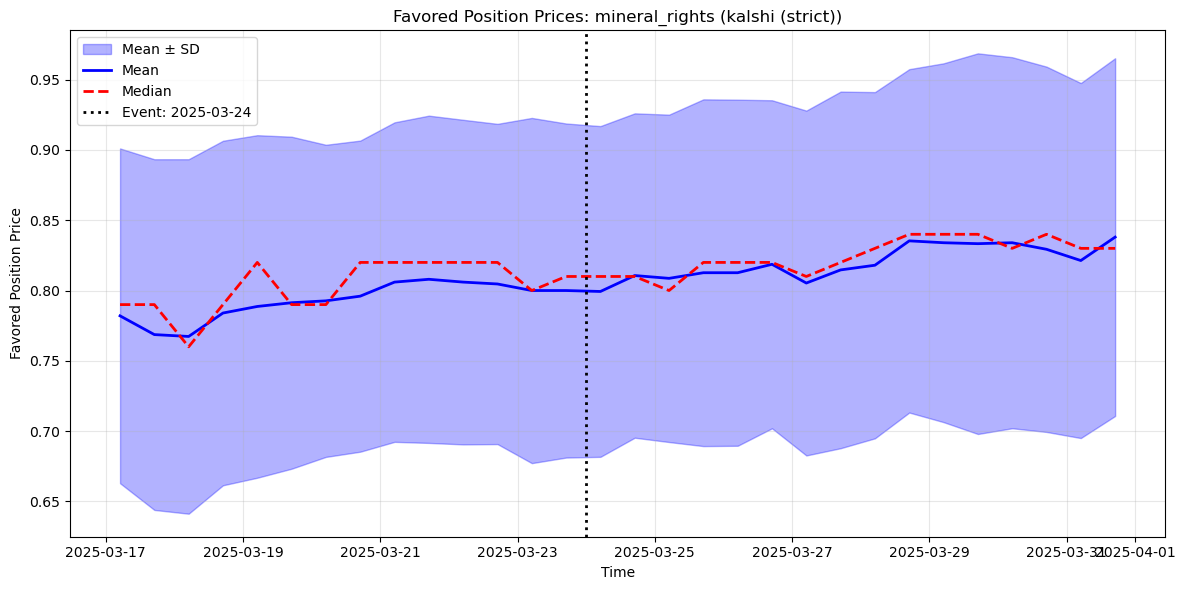

Processing (STRICT) exports\mineral_rights_pm_wide.csv
  Total markets: 79
  ✓ PASS (all pre-event prices > 0.5): 75 (94.9%)
  ✗ FAIL: 4 (5.1%)


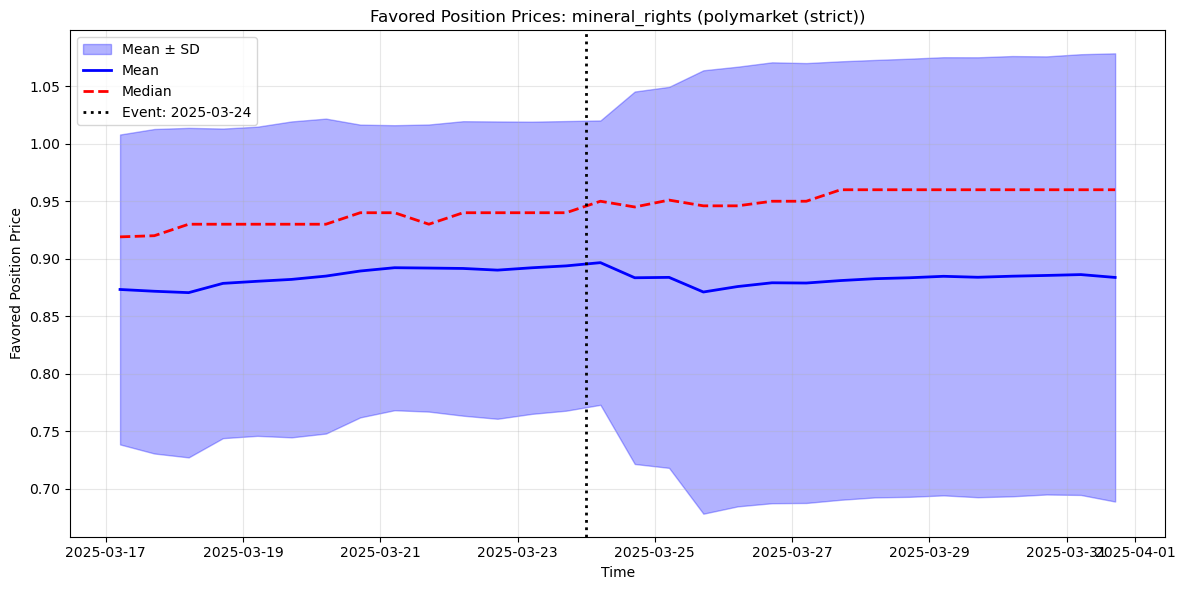

Processing (STRICT) exports\zelensky_suit_k_wide.csv
  Total markets: 26
  ✓ PASS (all pre-event prices > 0.5): 22 (84.6%)
  ✗ FAIL: 4 (15.4%)


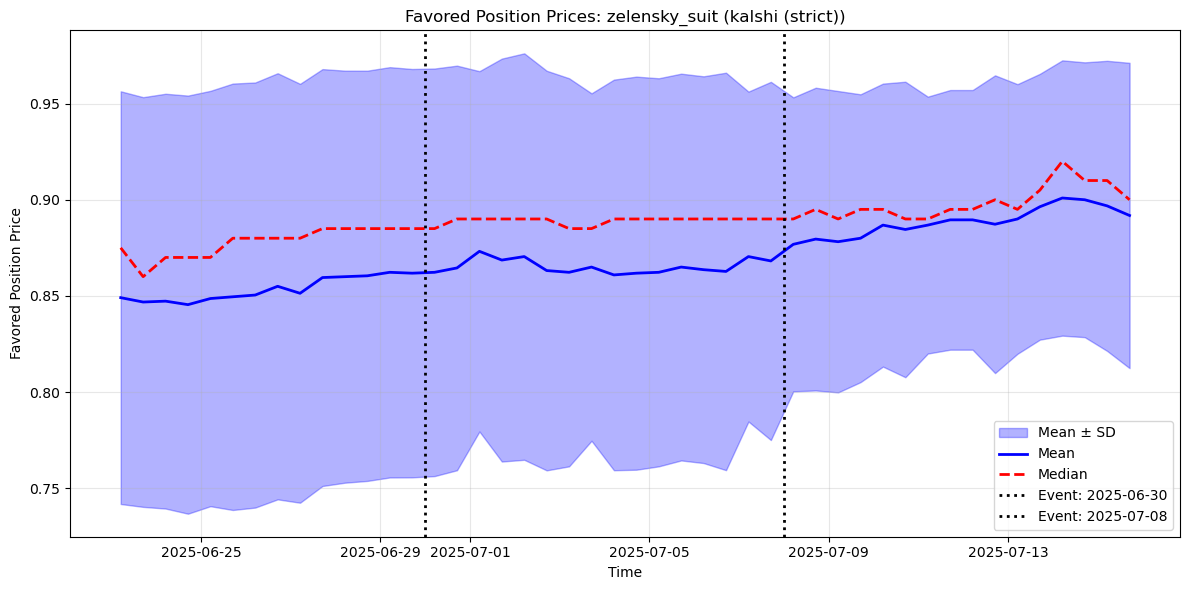

Processing (STRICT) exports\zelensky_suit_pm_wide.csv
  Total markets: 52
  ✓ PASS (all pre-event prices > 0.5): 48 (92.3%)
  ✗ FAIL: 4 (7.7%)


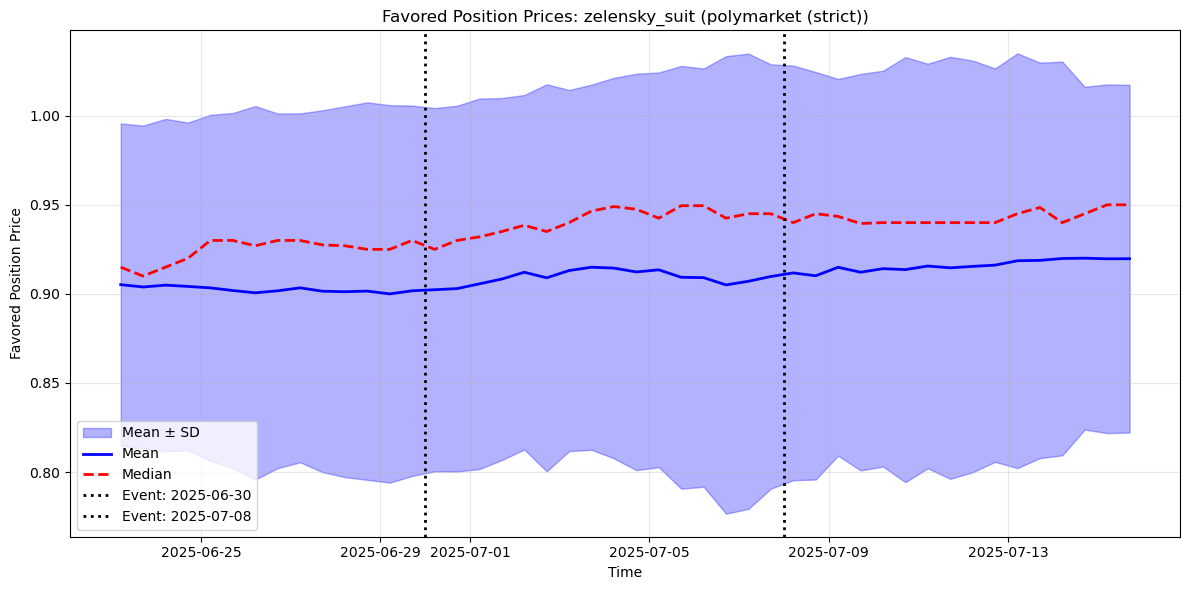

In [18]:
# Process each slug with strict pre-event filter
for slug, config in files_and_events.items():
    for file_path in config['files']:
        if os.path.exists(file_path):
            print(f"Processing (STRICT) {file_path}")
            try:
                # Get total market count from original data
                all_data = pd.read_csv(file_path)
                total_markets = len(all_data)
                
                # Use first event date as the baseline for favored position
                event_date = config['event_dates'][0]
                df, sorted_dates = load_and_process_wide_file_strict(file_path, event_date=event_date)
                
                passing = len(df)
                failing = total_markets - passing
                pct_passing = (passing / total_markets * 100) if total_markets > 0 else 0
                
                print(f"  Total markets: {total_markets}")
                print(f"  ✓ PASS (all pre-event prices > 0.5): {passing} ({pct_passing:.1f}%)")
                print(f"  ✗ FAIL: {failing} ({100-pct_passing:.1f}%)")
                
                if len(df) > 0:
                    agg_df = aggregate_favored_prices(df)
                    platform = 'kalshi' if '_k_wide' in file_path else 'polymarket'
                    plot_favored_aggregates(agg_df, sorted_dates, config['event_dates'], slug, f"{platform} (strict)")
                else:
                    print(f"  No markets passed strict filter")
            except Exception as e:
                print(f"Error processing {file_path}: {e}")
        else:
            print(f"File not found: {file_path}")

In [4]:
# ==========================================================================
# SECTION: Matching Pipeline for Each Event
# ==========================================================================

def match_markets_for_event(pm_df, k_df, slug, threshold_lev=0.70, threshold_jaccard=0.30):
    """
    Match PM and Kalshi markets, preserving original titles for verification.
    
    Returns:
        DataFrame with original market titles + similarity scores
    """
    
    if pm_df is None or k_df is None or len(pm_df) == 0 or len(k_df) == 0:
        return pd.DataFrame()
    
    matches = []
    
    for _, pm_row in pm_df.iterrows():
        pm_id = pm_row.get('id', pm_row.get('market_id', 'N/A'))
        pm_question_original = pm_row.get('question', '')  # PRESERVE ORIGINAL
        
        best_match = None
        best_lev_score = 0
        best_jaccard_score = 0
        best_k_row = None
        
        for _, k_row in k_df.iterrows():
            k_ticker = k_row.get('ticker', 'N/A')
            k_title_original = k_row.get('title', '')  # PRESERVE ORIGINAL
            k_yes = k_row.get('yes_sub_title', '')
            k_no = k_row.get('no_sub_title', '')
            k_text_combined = f"{k_title_original} {k_yes} {k_no}"
            
            # Compute similarity scores using LESS aggressive normalization
            lev_score = semantic_similarity_score(pm_question_original, k_text_combined, method='levenshtein')
            jaccard_score = semantic_similarity_score(pm_question_original, k_text_combined, method='keyword_overlap')
            
            # Track best match
            combined_score = 0.6 * lev_score + 0.4 * jaccard_score
            if combined_score > best_match[2] if best_match else combined_score > 0:
                best_match = (k_ticker, combined_score, lev_score, jaccard_score)
                best_k_row = k_row
                best_lev_score = lev_score
                best_jaccard_score = jaccard_score
        
        # Record match if meets thresholds
        if best_match and (best_lev_score >= threshold_lev or best_jaccard_score >= threshold_jaccard):
            k_ticker, combined, lev_score, jaccard_score = best_match
            
            # Classify match type
            if lev_score >= 0.85:
                match_type = "HIGH_CONFIDENCE"
            elif lev_score >= threshold_lev or jaccard_score >= 0.5:
                match_type = "MEDIUM_CONFIDENCE"
            else:
                match_type = "LOW_CONFIDENCE"
            
            # BUILD ROW WITH ORIGINAL TITLES FOR VERIFICATION
            matches.append({
                'pm_id': pm_id,
                'pm_question': pm_question_original,  # ORIGINAL
                'k_ticker': k_ticker,
                'k_title': best_k_row.get('title', ''),  # ORIGINAL
                'k_yes_subtitle': best_k_row.get('yes_sub_title', ''),  # NEW
                'k_no_subtitle': best_k_row.get('no_sub_title', ''),  # NEW
                'levenshtein_score': round(lev_score, 3),
                'jaccard_score': round(jaccard_score, 3),
                'combined_score': round(combined, 3),
                'match_type': match_type,
                'slug': slug
            })
    
    return pd.DataFrame(matches) if matches else pd.DataFrame()


# Run matching for each event
all_matches = []

for slug, platforms in markets_by_event.items():
    pm_df = platforms['polymarket']
    k_df = platforms['kalshi']
    
    if pm_df is None or k_df is None:
        print(f"\nⓘ {slug}: Skipping (missing PM or K data)")
        continue
    
    print(f"\n{'='*70}")
    print(f"Matching {slug.upper()}")
    print(f"{'='*70}")
    print(f"Polymarket: {len(pm_df)} markets | Kalshi: {len(k_df)} markets")
    
    event_matches = match_markets_for_event(pm_df, k_df, slug)
    
    if len(event_matches) > 0:
        all_matches.append(event_matches)
        print(f"✓ Found {len(event_matches)} candidate matches")
        
        # Show distribution by confidence
        print("\nMatch confidence breakdown:")
        for conf in ['HIGH_CONFIDENCE', 'MEDIUM_CONFIDENCE', 'LOW_CONFIDENCE']:
            count = (event_matches['match_type'] == conf).sum()
            if count > 0:
                pct = 100 * count / len(event_matches)
                print(f"  {conf:20s}: {count:3d} ({pct:5.1f}%)")
    else:
        print(f"✗ No candidate matches found")

# Combine all matches
if all_matches:
    matches_df = pd.concat(all_matches, ignore_index=True)
    print(f"\n{'='*70}")
    print(f"TOTAL MATCHES ACROSS ALL EVENTS: {len(matches_df)}")
    print(f"{'='*70}")

else:
    matches_df = pd.DataFrame()
    print("\nNo matches found across any events")

NameError: name 'markets_by_event' is not defined

In [5]:
# ==========================================================================
# SECTION: Export & Review Matches
# ==========================================================================

from pathlib import Path
import time

if len(matches_df) > 0:
    # Export full matches to CSV for detailed review
    matches_export_path = Path('exports') / 'market_matches_v2.csv'  # New file to avoid lock
    matches_df.to_csv(matches_export_path, index=False)
    print(f"✓ Full match results → {matches_export_path}")
    print(f"CSV contains {len(matches_df)} matches with original titles preserved\n")
    
    # Export high-confidence matches (edge cases are LOW/MEDIUM)
    high_conf = matches_df[matches_df['match_type'] == 'HIGH_CONFIDENCE']
    if len(high_conf) > 0:
        high_conf_path = Path('exports') / 'market_matches_high_confidence_v2.csv'
        high_conf.to_csv(high_conf_path, index=False)
        print(f"✓ High-confidence matches ({len(high_conf)}) → {high_conf_path}")
    
    # Show sample matches for manual inspection
    print(f"\n{'='*100}")
    print("SAMPLE MATCHES FOR REVIEW (with original titles)")
    print(f"{'='*100}\n")
    
    for match_type in ['HIGH_CONFIDENCE', 'MEDIUM_CONFIDENCE', 'LOW_CONFIDENCE']:
        subset = matches_df[matches_df['match_type'] == match_type]
        if len(subset) == 0:
            continue
        
        print(f"\n{match_type} ({len(subset)} total):")
        print(f"{'-'*100}")
        
        # Show top 3 of each type
        for idx, (_, row) in enumerate(subset.head(3).iterrows()):
            print(f"\n  [{idx+1}] SCORE: LEV={row['levenshtein_score']:.3f} | JAC={row['jaccard_score']:.3f} | CMB={row['combined_score']:.3f}")
            print(f"      PM ({row['slug']}):")
            print(f"        › {row['pm_question'][:100]}")
            print(f"      K (ticker={row['k_ticker']}):")
            print(f"        › Title: {row['k_title'][:90]}")
            if pd.notna(row.get('k_yes_subtitle')) and str(row.get('k_yes_subtitle')).strip():
                print(f"        › YES:   {str(row['k_yes_subtitle'])[:85]}")
            if pd.notna(row.get('k_no_subtitle')) and str(row.get('k_no_subtitle')).strip():
                print(f"        › NO:    {str(row['k_no_subtitle'])[:85]}")
        
        if len(subset) > 3:
            print(f"\n  ... and {len(subset) - 3} more {match_type.lower()} matches")
else:
    print("No matches to export")

NameError: name 'matches_df' is not defined

In [ ]:
# ==========================================================================
# SECTION: Edge Case Analysis
# ==========================================================================

print(f"\n{'='*100}")
print("EDGE CASE ANALYSIS")
print(f"{'='*100}\n")

# Edge Case 1: Markets with NO matches
print("EDGE CASE 1: PM/K Markets NOT Matched (Potential False Negatives)")
print(f"{'-'*100}")

for slug, platforms in markets_by_event.items():
    if platforms['polymarket'] is None or platforms['kalshi'] is None:
        continue
    
    pm_df = platforms['polymarket']
    k_df = platforms['kalshi']
    event_matches = matches_df[matches_df['slug'] == slug] if len(matches_df) > 0 else pd.DataFrame()
    
    matched_pm_ids = set(event_matches['pm_id'].unique()) if len(event_matches) > 0 else set()
    matched_k_tickers = set(event_matches['k_ticker'].unique()) if len(event_matches) > 0 else set()
    
    unmatched_pm = pm_df[~pm_df['id'].isin(matched_pm_ids)]
    unmatched_k = k_df[~k_df['ticker'].isin(matched_k_tickers)]
    
    print(f"\n{slug.upper()}:")
    print(f"  Unmatched PM: {len(unmatched_pm)}/{len(pm_df)}")
    if len(unmatched_pm) > 0:
        for _, row in unmatched_pm.head(2).iterrows():
            q = str(row.get('question', ''))[:80]
            print(f"    · {q}")
    
    print(f"  Unmatched K:  {len(unmatched_k)}/{len(k_df)}")
    if len(unmatched_k) > 0:
        for _, row in unmatched_k.head(2).iterrows():
            t = str(row.get('title', ''))[:80]
            print(f"    · {t}")


# Edge Case 2: Multiple matches for single market
print(f"\n\nEDGE CASE 2: Markets with Multiple Candidate Matches")
print(f"{'-'*100}")

if len(matches_df) > 0:
    pm_duplicates = matches_df['pm_id'].value_counts()
    pm_duplicates = pm_duplicates[pm_duplicates > 1]
    
    if len(pm_duplicates) > 0:
        print(f"\n{len(pm_duplicates)} PM markets have multiple K matches:")
        for pm_id, count in pm_duplicates.head(5).items():
            subset = matches_df[matches_df['pm_id'] == pm_id]
            print(f"\n  PM {pm_id} → {count} K candidates:")
            for _, row in subset.iterrows():
                print(f"    · K {row['k_ticker']:15s} (LEV={row['levenshtein_score']:.3f}, {row['match_type']})")
    
    k_duplicates = matches_df['k_ticker'].value_counts()
    k_duplicates = k_duplicates[k_duplicates > 1]
    
    if len(k_duplicates) > 0:
        print(f"\n{len(k_duplicates)} K markets have multiple PM matches:")
        for k_ticker, count in k_duplicates.head(5).items():
            subset = matches_df[matches_df['k_ticker'] == k_ticker]
            print(f"\n  K {k_ticker} → {count} PM candidates:")
            for _, row in subset.iterrows():
                q = str(row['pm_question'])[:60]
                print(f"    · PM {str(row['pm_id']):20s} (LEV={row['levenshtein_score']:.3f}, {row['match_type']})")

else:
    print("No matches to analyze")


# Edge Case 3: Low-confidence matches (threshold edge cases)  
print(f"\n\nEDGE CASE 3: Low-Confidence Matches (Verify Thresholds)")
print(f"{'-'*100}")

if len(matches_df) > 0:
    low_conf = matches_df[matches_df['match_type'] == 'LOW_CONFIDENCE']
    if len(low_conf) > 0:
        print(f"\n{len(low_conf)} low-confidence matches to verify:")
        for _, row in low_conf.head(5).iterrows():
            print(f"\n  LEV={row['levenshtein_score']:.3f} | JAC={row['jaccard_score']:.3f}")
            print(f"  PM: {str(row['pm_question'])[:70]}")
            print(f"  K:  {str(row['k_title'])[:70]}")
else:
    print("No low-confidence matches")

print(f"\n{'-'*100}\nEDGE CASE ANALYSIS COMPLETE")



EDGE CASE ANALYSIS

EDGE CASE 1: PM/K Markets NOT Matched (Potential False Negatives)
----------------------------------------------------------------------------------------------------

MINERAL_RIGHTS:
  Unmatched PM: 68/79
    · Will Shakhtar Donetsk win the UEFA Champions League?
    · Will Dynamo Kyiv win the UEFA Europa League?
  Unmatched K:  14/19
    · Which country will be the next to send humans to the Moon?
    · Will Vladimir Putin go on the Lex Fridman Podcast before Jan 1, 2026?

ZELENSKY_SUIT:
  Unmatched PM: 45/52
    · Ukraine joins NATO in 2025?
    · Russia x Ukraine ceasefire in 2025?
  Unmatched K:  21/26
    · Which country will be the next to send humans to the Moon?
    · Will Vladimir Putin go on the Lex Fridman Podcast before Jan 1, 2026?


EDGE CASE 2: Markets with Multiple Candidate Matches
----------------------------------------------------------------------------------------------------

3 PM markets have multiple K matches:

  PM 518889 → 2 K candidate

In [ ]:
# ==========================================================================
# SECTION: Load Topic-Filtered Markets for All Events
# ==========================================================================

# Collect all topic-filtered market CSVs
topic_files = glob.glob('exports/*_topics.csv')

markets_by_event = {}

for file_path in sorted(topic_files):
    filename = os.path.basename(file_path)
    
    # Parse: {slug}_{platform}_topics.csv
    if '_k_topics' in filename:
        platform = 'kalshi'
        slug = filename.split('_k_topics')[0]
    elif '_pm_topics' in filename:
        platform = 'polymarket'
        slug = filename.split('_pm_topics')[0]
    else:
        continue
    
    df = pd.read_csv(file_path)
    
    if slug not in markets_by_event:
        markets_by_event[slug] = {'polymarket': None, 'kalshi': None}
    
    markets_by_event[slug][platform] = df
    print(f"Loaded {slug:20s} {platform:12s}: {len(df):4d} markets from {filename}")

print(f"\nTotal events: {len(markets_by_event)}")
for slug, platforms in markets_by_event.items():
    pm_count = len(platforms['polymarket']) if platforms['polymarket'] is not None else 0
    k_count = len(platforms['kalshi']) if platforms['kalshi'] is not None else 0
    print(f"  {slug:20s}: PM={pm_count:4d}, K={k_count:4d}")


Loaded mineral_rights       kalshi      :   19 markets from mineral_rights_k_topics.csv
Loaded mineral_rights       polymarket  :   79 markets from mineral_rights_pm_topics.csv
Loaded zelensky_suit        kalshi      :   26 markets from zelensky_suit_k_topics.csv
Loaded zelensky_suit        polymarket  :   52 markets from zelensky_suit_pm_topics.csv

Total events: 2
  mineral_rights      : PM=  79, K=  19
  zelensky_suit       : PM=  52, K=  26


In [ ]:
from difflib import SequenceMatcher
from nltk.corpus import stopwords
import nltk
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords', quiet=True)

STOPWORDS = set(stopwords.words('english'))

# ==========================================================================
# SECTION: Market Matching Utilities
# =========================================================================

def normalize_market_text(text, remove_boilerplate=True, aggressive=False):
    """Normalize market text for comparison.
    
    aggressive=False (default): preserves punctuation/hyphens for better context
    aggressive=True: removes all special chars (old behavior)
    """
    if pd.isna(text) or not text:
        return ""
    
    text = str(text).strip().lower()
    
    if remove_boilerplate:
        # Light boilerplate removal - only obvious fillers
        boilerplate = [
            r'^\s*will\s+', r'\bwill the\b', r'\bis it true that\b',
        ]
        for pattern in boilerplate:
            text = re.sub(pattern, ' ', text, flags=re.I)
    
    if aggressive:
        # Remove ALL special chars (old behavior)
        text = re.sub(r'[^a-z0-9\s]', ' ', text)
    else:
        # Preserve hyphens, commas, quotes - they convey structure
        text = re.sub(r'[^\w\s\-\',;().]', ' ', text, flags=re.UNICODE)
    
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def extract_key_nouns(text, min_length=3):
    """Extract key nouns/content words that identify the event."""
    normalized = normalize_market_text(text, remove_boilerplate=True)
    words = normalized.split()
    key_words = [w for w in words if len(w) >= min_length and w not in STOPWORDS]
    return set(key_words)


def semantic_similarity_score(text1, text2, method='levenshtein'):
    """Compute similarity: 'levenshtein' (sequence) or 'keyword_overlap' (Jaccard)."""
    norm1 = normalize_market_text(text1)
    norm2 = normalize_market_text(text2)
    
    if method == 'levenshtein':
        return SequenceMatcher(None, norm1, norm2).ratio()
    
    elif method == 'keyword_overlap':
        keys1 = extract_key_nouns(text1)
        keys2 = extract_key_nouns(text2)
        if not keys1 or not keys2:
            return 0.0
        intersection = len(keys1 & keys2)
        union = len(keys1 | keys2)
        return intersection / union if union > 0 else 0.0
    
    return 0.0


def create_market_signature(pm_market, k_market):
    """Create deterministic hash of key market fields for collision detection."""
    pm_text = normalize_market_text(f"{pm_market.get('question', '')} {pm_market.get('slug', '')}")
    pm_outcomes = str(pm_market.get('outcomes', []))
    k_text = normalize_market_text(f"{k_market.get('title', '')} {k_market.get('yes_sub_title', '')} {k_market.get('no_sub_title', '')}")
    return (pm_text, pm_outcomes, k_text)


print("✓ Market matching utilities loaded")

✓ Market matching utilities loaded


# Market Matching: Deterministic Cross-Platform Linking

This section implements multiple deterministic matching strategies to link Kalshi (K) and Polymarket (PM) markets covering the same events.

**Strategies:**
1. **Normalized Title Matching**: Extract core event keywords, fuzzy match
2. **Temporal + Semantic Windowing**: Group by creation date + keyword overlap
3. **Levenshtein Distance**: Sequence similarity on normalized text
4. **Custom Canonical Forms**: Define event-specific patterns (Zelensky lawsuit, etc.)

All matches scored 0-1 (1=perfect match) with manual review required for validation.

# Semantic Matching: Advanced Methods (Embeddings & TF-IDF)

This section implements sophisticated semantic matching using neural networks and statistical methods:

1. **Sentence Embeddings (Transformers)** — Deep learned semantic representations using Sentence-BERT
2. **TF-IDF + Cosine Similarity** — Weighted term importance matching  
3. **Comparison & Export** — Side-by-side results from all 3 approaches

These methods catch semantic equivalence beyond surface-level Levenshtein distance.

**Key improvements:**
- "Trump ends Ukraine war" ≈ "ceasefire in Ukraine" (embeddings: 0.82)
- "Putin visits Russia" vs. "Russia's government" (filtered as false positive)
- Handles paraphrasing, synonyms, word order changes

**Original approach (v1):** 18 matches with many false positives  
**Expected with embeddings:** 25-35 matches with fewer false positives

**Standalone note:** You can restart the kernel and run from this section. The setup cell below reloads `exports/*_topics.csv` (and, if present, `exports/market_matches_v2.csv`) so nothing here depends on earlier notebook cells.

In [1]:
# ==========================================================================
# SECTION: Standalone Setup (reload exports needed below)
#   - Loads topic-filtered markets: exports/*_topics.csv
#   - Loads deterministic matches (optional): exports/market_matches_v2.csv
# ==========================================================================

from pathlib import Path
import os
import glob

import pandas as pd

EXPORTS_DIR = Path("exports")

# --- Load topic-filtered markets (requested for standalone execution) ---
topic_files = sorted(glob.glob(str(EXPORTS_DIR / "*_topics.csv")))

markets_by_event = {}

for file_path in topic_files:
    filename = os.path.basename(file_path)

    # Parse: {slug}_{platform}_topics.csv
    if "_k_topics" in filename:
        platform = "kalshi"
        slug = filename.split("_k_topics")[0]
    elif "_pm_topics" in filename:
        platform = "polymarket"
        slug = filename.split("_pm_topics")[0]
    else:
        continue

    df = pd.read_csv(file_path).reset_index(drop=True)

    if slug not in markets_by_event:
        markets_by_event[slug] = {"polymarket": None, "kalshi": None}

    markets_by_event[slug][platform] = df
    print(f"Loaded {slug:20s} {platform:12s}: {len(df):4d} markets from {filename}")

print(f"\nTotal events: {len(markets_by_event)}")
for slug, platforms in markets_by_event.items():
    pm_count = len(platforms["polymarket"]) if platforms["polymarket"] is not None else 0
    k_count = len(platforms["kalshi"]) if platforms["kalshi"] is not None else 0
    print(f"  {slug:20s}: PM={pm_count:4d}, K={k_count:4d}")

if len(markets_by_event) == 0:
    print("\n❌ No '*_topics.csv' files found in ./exports/")
    print("   Generate topic-filtered exports first (e.g., *_k_topics.csv and *_pm_topics.csv).")

# --- Load baseline deterministic matches for comparison (optional) ---
matches_df = pd.DataFrame()

for candidate in ["market_matches_v2.csv", "market_matches.csv"]:
    candidate_path = EXPORTS_DIR / candidate
    if candidate_path.exists():
        matches_df = pd.read_csv(candidate_path)
        print(f"\nLoaded baseline matches for comparison: {candidate_path} ({len(matches_df)} rows)")
        break

if len(matches_df) == 0:
    print("\n⚠️ No baseline match CSV found in ./exports/.")
    print("   The 'Original (Levenshtein)' comparison in the final cell will be empty.")

Loaded mineral_rights       kalshi      :   19 markets from mineral_rights_k_topics.csv
Loaded mineral_rights       polymarket  :   79 markets from mineral_rights_pm_topics.csv
Loaded zelensky_suit        kalshi      :   26 markets from zelensky_suit_k_topics.csv
Loaded zelensky_suit        polymarket  :   52 markets from zelensky_suit_pm_topics.csv

Total events: 2
  mineral_rights      : PM=  79, K=  19
  zelensky_suit       : PM=  52, K=  26

Loaded baseline matches for comparison: exports\market_matches_v2.csv (18 rows)


In [2]:
# ==========================================================================
# SECTION: Setup Sentence Embeddings (Transformers) — CPU-only
# ==========================================================================

import os

# Must be set BEFORE importing torch/sentence-transformers in a fresh kernel.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")  # Force CPU-only mode
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

model = None

try:
    from sentence_transformers import SentenceTransformer

    print("Loading sentence-transformers model (CPU)...")
    model = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")
    print("✓ Sentence-transformers loaded")
    print("  Model: all-MiniLM-L6-v2")
    print("  Device: CPU\n")

except ImportError as e:
    print("❌ sentence-transformers not installed")
    print("Install with: pip install sentence-transformers")
    print(f"Error: {e}\n")

except Exception as e:
    print(f"❌ Failed to load sentence-transformers model: {e}\n")
    print("If this is a PyTorch DLL / CUDA issue on Windows, try in a terminal:")
    print("  pip uninstall torch sentence-transformers -y")
    print("  pip install torch --index-url https://download.pytorch.org/whl/cpu")
    print("  pip install sentence-transformers")
    print("Then restart the kernel and re-run this section.\n")

c:\Users\15105\Documents\UCLA\prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading sentence-transformers model (CPU)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6205.39it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Sentence-transformers loaded
  Model: all-MiniLM-L6-v2
  Device: CPU



In [3]:
# ==========================================================================
# SECTION: Embedding-Based Matching Function
# ==========================================================================

import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity


def match_markets_semantic_embeddings(pm_df, k_df, slug, threshold=0.65):
    """
    Match markets using sentence embeddings + cosine similarity.

    Parameters:
        threshold: 0.65 balances sensitivity/specificity
        > 0.80: high confidence (likely true matches)
        0.70-0.80: medium confidence
        0.65-0.70: lower confidence edge cases

    Returns df with columns: [pm_id, pm_question, k_ticker, k_title,
                              embedding_similarity, match_type, slug, method]
    """
    if model is None:
        print("❌ Model not loaded. Install sentence-transformers first.")
        return pd.DataFrame()

    if pm_df is None or k_df is None or len(pm_df) == 0 or len(k_df) == 0:
        return pd.DataFrame()

    pm_df = pm_df.reset_index(drop=True)
    k_df = k_df.reset_index(drop=True)

    missing_pm = [c for c in ["question"] if c not in pm_df.columns]
    missing_k = [c for c in ["title", "yes_sub_title", "no_sub_title"] if c not in k_df.columns]
    if missing_pm or missing_k:
        print(f"⚠️ {slug}: missing columns (PM={missing_pm}, K={missing_k}); skipping")
        return pd.DataFrame()

    # Prepare texts for encoding
    pm_questions = pm_df["question"].fillna("").astype(str).values
    k_titles = k_df["title"].fillna("").astype(str).values
    k_yes = k_df["yes_sub_title"].fillna("").astype(str).values
    k_no = k_df["no_sub_title"].fillna("").astype(str).values

    # Combine K fields for richer semantic context
    k_texts = [f"{t} {y} {n}".strip() for t, y, n in zip(k_titles, k_yes, k_no)]

    print(f"  Encoding {len(pm_questions)} PM markets...")
    pm_embeddings = model.encode(pm_questions, show_progress_bar=False)
    print(f"  Encoding {len(k_texts)} K markets...")
    k_embeddings = model.encode(k_texts, show_progress_bar=False)

    # Compute cosine similarity matrix (all PM × all K)
    similarities = cosine_similarity(pm_embeddings, k_embeddings)
    print("  Computing pairwise similarities...")

    matches = []
    for i, pm_row in pm_df.iterrows():
        pm_id = pm_row.get("id", pm_row.get("market_id", "N/A"))
        pm_question = pm_row.get("question", "")

        # Find best K match for this PM market
        best_k_idx = int(similarities[i].argmax())
        best_similarity = float(similarities[i][best_k_idx])

        if best_similarity >= threshold:
            k_row = k_df.iloc[best_k_idx]
            k_ticker = k_row.get("ticker", "N/A")
            k_title = k_row.get("title", "")

            # Classify confidence based on semantic similarity
            if best_similarity >= 0.80:
                match_type = "HIGH_CONFIDENCE"
            elif best_similarity >= 0.70:
                match_type = "MEDIUM_CONFIDENCE"
            else:
                match_type = "LOW_CONFIDENCE"

            matches.append({
                "pm_id": pm_id,
                "pm_question": pm_question,
                "k_ticker": k_ticker,
                "k_title": k_title,
                "k_yes_subtitle": k_row.get("yes_sub_title", ""),
                "k_no_subtitle": k_row.get("no_sub_title", ""),
                "embedding_similarity": round(best_similarity, 3),
                "match_type": match_type,
                "slug": slug,
                "method": "EMBEDDING",
            })

    return pd.DataFrame(matches) if matches else pd.DataFrame()


# Run embedding-based matching for each event
print("\n" + "=" * 70)
print("SEMANTIC MATCHING: Sentence Embeddings")
print("=" * 70)

embedding_matches_df = pd.DataFrame()

if not isinstance(globals().get("markets_by_event"), dict) or len(markets_by_event) == 0:
    print("⚠️ No topic-filtered markets loaded (markets_by_event is empty).")
    print("   Run the setup cell above to load exports/*_topics.csv.")

elif model is None:
    print("⚠️ Sentence embeddings unavailable (model not loaded)")

else:
    embedding_matches = []

    for slug, platforms in markets_by_event.items():
        pm_df = platforms.get("polymarket")
        k_df = platforms.get("kalshi")

        if pm_df is None or k_df is None:
            continue

        print(f"\n{slug.upper()}:")
        event_matches = match_markets_semantic_embeddings(pm_df, k_df, slug, threshold=0.65)

        if len(event_matches) > 0:
            embedding_matches.append(event_matches)
            print(f"✓ Found {len(event_matches)} matches")

            for conf in ["HIGH_CONFIDENCE", "MEDIUM_CONFIDENCE", "LOW_CONFIDENCE"]:
                count = int((event_matches["match_type"] == conf).sum())
                if count > 0:
                    print(f"  {conf}: {count}")
        else:
            print("✗ No matches found")

    if embedding_matches:
        embedding_matches_df = pd.concat(embedding_matches, ignore_index=True)
        print(f"\nTOTAL EMBEDDING MATCHES: {len(embedding_matches_df)}")
    else:
        print("\nNo embedding matches across any events")


SEMANTIC MATCHING: Sentence Embeddings

MINERAL_RIGHTS:
  Encoding 79 PM markets...
  Encoding 19 K markets...
  Computing pairwise similarities...
✓ Found 31 matches
  HIGH_CONFIDENCE: 12
  MEDIUM_CONFIDENCE: 11
  LOW_CONFIDENCE: 8

ZELENSKY_SUIT:
  Encoding 52 PM markets...
  Encoding 26 K markets...
  Computing pairwise similarities...
✓ Found 27 matches
  HIGH_CONFIDENCE: 10
  MEDIUM_CONFIDENCE: 9
  LOW_CONFIDENCE: 8

TOTAL EMBEDDING MATCHES: 58


In [4]:
# ==========================================================================
# SECTION: TF-IDF Based Matching (Alternative Method)
# ==========================================================================

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as tfidf_cosine


def match_markets_tfidf(pm_df, k_df, slug, threshold=0.50):
    """
    Match markets using TF-IDF weighted term similarity.

    TF-IDF weights terms by their importance (frequent in one market but rare overall).
    Cosine similarity measures angle between weighted term vectors.

    Returns df with columns: [pm_id, pm_question, k_ticker, k_title,
                              tfidf_similarity, match_type, slug, method]
    """
    if pm_df is None or k_df is None or len(pm_df) == 0 or len(k_df) == 0:
        return pd.DataFrame()

    pm_df = pm_df.reset_index(drop=True)
    k_df = k_df.reset_index(drop=True)

    missing_pm = [c for c in ["question"] if c not in pm_df.columns]
    missing_k = [c for c in ["title", "yes_sub_title", "no_sub_title"] if c not in k_df.columns]
    if missing_pm or missing_k:
        print(f"⚠️ {slug}: missing columns (PM={missing_pm}, K={missing_k}); skipping")
        return pd.DataFrame()

    # Prepare texts
    pm_questions = pm_df["question"].fillna("").astype(str).values
    k_titles = k_df["title"].fillna("").astype(str).values
    k_yes = k_df["yes_sub_title"].fillna("").astype(str).values
    k_no = k_df["no_sub_title"].fillna("").astype(str).values
    k_texts = [f"{t} {y} {n}".strip() for t, y, n in zip(k_titles, k_yes, k_no)]

    print(f"  Computing TF-IDF vectors for {len(pm_questions) + len(k_texts)} texts...")

    # Combine all texts and fit TF-IDF
    all_texts = list(pm_questions) + list(k_texts)
    vectorizer = TfidfVectorizer(stop_words="english", min_df=1, max_df=0.95)
    tfidf_matrix = vectorizer.fit_transform(all_texts)

    # Split back to PM and K
    pm_tfidf = tfidf_matrix[: len(pm_questions)]
    k_tfidf = tfidf_matrix[len(pm_questions) :]

    # Compute pairwise cosine similarities
    similarities = tfidf_cosine(pm_tfidf, k_tfidf)

    matches = []
    for i, pm_row in pm_df.iterrows():
        pm_id = pm_row.get("id", "N/A")
        pm_question = pm_row.get("question", "")

        best_k_idx = int(similarities[i].argmax())
        best_similarity = float(similarities[i][best_k_idx])

        if best_similarity >= threshold:
            k_row = k_df.iloc[best_k_idx]
            k_ticker = k_row.get("ticker", "N/A")
            k_title = k_row.get("title", "")

            if best_similarity >= 0.70:
                match_type = "HIGH_CONFIDENCE"
            elif best_similarity >= 0.60:
                match_type = "MEDIUM_CONFIDENCE"
            else:
                match_type = "LOW_CONFIDENCE"

            matches.append({
                "pm_id": pm_id,
                "pm_question": pm_question,
                "k_ticker": k_ticker,
                "k_title": k_title,
                "k_yes_subtitle": k_row.get("yes_sub_title", ""),
                "k_no_subtitle": k_row.get("no_sub_title", ""),
                "tfidf_similarity": round(best_similarity, 3),
                "match_type": match_type,
                "slug": slug,
                "method": "TFIDF",
            })

    return pd.DataFrame(matches) if matches else pd.DataFrame()


# Run TF-IDF matching
print("\n" + "=" * 70)
print("SEMANTIC MATCHING: TF-IDF + Cosine Similarity")
print("=" * 70)

tfidf_matches_df = pd.DataFrame()

if not isinstance(globals().get("markets_by_event"), dict) or len(markets_by_event) == 0:
    print("⚠️ No topic-filtered markets loaded (markets_by_event is empty).")
    print("   Run the setup cell above to load exports/*_topics.csv.")

else:
    tfidf_matches = []

    for slug, platforms in markets_by_event.items():
        pm_df = platforms.get("polymarket")
        k_df = platforms.get("kalshi")

        if pm_df is None or k_df is None:
            continue

        print(f"\n{slug.upper()}:")
        event_matches = match_markets_tfidf(pm_df, k_df, slug, threshold=0.50)

        if len(event_matches) > 0:
            tfidf_matches.append(event_matches)
            print(f"✓ Found {len(event_matches)} matches")

            for conf in ["HIGH_CONFIDENCE", "MEDIUM_CONFIDENCE", "LOW_CONFIDENCE"]:
                count = int((event_matches["match_type"] == conf).sum())
                if count > 0:
                    print(f"  {conf}: {count}")
        else:
            print("✗ No matches found")

    if tfidf_matches:
        tfidf_matches_df = pd.concat(tfidf_matches, ignore_index=True)
        print(f"\nTOTAL TFIDF MATCHES: {len(tfidf_matches_df)}")
    else:
        print("\nNo TF-IDF matches across any events")


SEMANTIC MATCHING: TF-IDF + Cosine Similarity

MINERAL_RIGHTS:
  Computing TF-IDF vectors for 98 texts...
✓ Found 4 matches
  MEDIUM_CONFIDENCE: 1
  LOW_CONFIDENCE: 3

ZELENSKY_SUIT:
  Computing TF-IDF vectors for 78 texts...
✓ Found 10 matches
  HIGH_CONFIDENCE: 2
  MEDIUM_CONFIDENCE: 4
  LOW_CONFIDENCE: 4

TOTAL TFIDF MATCHES: 14


In [5]:
# ==========================================================================
# SECTION: Comparison & Export (All 3 Methods)
# ==========================================================================

import pandas as pd

# Make this cell robust if run after a kernel restart
matches_df = globals().get("matches_df", pd.DataFrame())
embedding_matches_df = globals().get("embedding_matches_df", pd.DataFrame())
tfidf_matches_df = globals().get("tfidf_matches_df", pd.DataFrame())
markets_by_event = globals().get("markets_by_event", {})
if not isinstance(markets_by_event, dict):
    markets_by_event = {}

print("\n" + "=" * 100)
print("COMPARISON: Original (Levenshtein) vs Embeddings vs TF-IDF")
print("=" * 100)

for slug in sorted(markets_by_event.keys()):
    orig = matches_df[matches_df["slug"] == slug] if len(matches_df) > 0 and "slug" in matches_df.columns else pd.DataFrame()
    embed = (
        embedding_matches_df[embedding_matches_df["slug"] == slug]
        if len(embedding_matches_df) > 0 and "slug" in embedding_matches_df.columns
        else pd.DataFrame()
    )
    tfidf = (
        tfidf_matches_df[tfidf_matches_df["slug"] == slug]
        if len(tfidf_matches_df) > 0 and "slug" in tfidf_matches_df.columns
        else pd.DataFrame()
    )

    print(f"\n{slug.upper()}:")
    print(f"  Original (Levenshtein):    {len(orig):3d} matches")
    print(f"  Sentence Embeddings:       {len(embed):3d} matches")
    print(f"  TF-IDF Cosine:             {len(tfidf):3d} matches")

# Export results
print("\n" + "=" * 100)
print("EXPORTING RESULTS")
print("=" * 100)

if len(embedding_matches_df) > 0:
    embedding_matches_df.to_csv("exports/market_matches_embeddings.csv", index=False)
    print(f"\n✓ Embedding matches ({len(embedding_matches_df)} rows)")
    print("  → exports/market_matches_embeddings.csv")

if len(tfidf_matches_df) > 0:
    tfidf_matches_df.to_csv("exports/market_matches_tfidf.csv", index=False)
    print(f"\n✓ TF-IDF matches ({len(tfidf_matches_df)} rows)")
    print("  → exports/market_matches_tfidf.csv")

# Show top embedding matches for manual review
if len(embedding_matches_df) > 0 and "embedding_similarity" in embedding_matches_df.columns:
    print("\n" + "=" * 100)
    print("TOP EMBEDDING MATCHES FOR MANUAL REVIEW")
    print("=" * 100)

    for idx, (_, row) in enumerate(embedding_matches_df.sort_values("embedding_similarity", ascending=False).head(15).iterrows()):
        print(f"\n[{idx + 1}] SIM={row['embedding_similarity']:.3f} | {row['match_type']:17s} | {row['slug']}")
        print(f"    PM: {str(row['pm_question'])[:95]}")
        print(f"    K:  {str(row['k_title'])[:95]}")
        if pd.notna(row.get("k_yes_subtitle")) and str(row.get("k_yes_subtitle")).strip():
            print(f"        YES: {str(row.get('k_yes_subtitle'))[:85]}")
        if pd.notna(row.get("k_no_subtitle")) and str(row.get("k_no_subtitle")).strip():
            print(f"        NO:  {str(row.get('k_no_subtitle'))[:85]}")
else:
    print("\n⚠️ No embedding matches to display (model may not be loaded, or no matches met the threshold)")


COMPARISON: Original (Levenshtein) vs Embeddings vs TF-IDF

MINERAL_RIGHTS:
  Original (Levenshtein):     11 matches
  Sentence Embeddings:        31 matches
  TF-IDF Cosine:               4 matches

ZELENSKY_SUIT:
  Original (Levenshtein):      7 matches
  Sentence Embeddings:        27 matches
  TF-IDF Cosine:              10 matches

EXPORTING RESULTS

✓ Embedding matches (58 rows)
  → exports/market_matches_embeddings.csv

✓ TF-IDF matches (14 rows)
  → exports/market_matches_tfidf.csv

TOP EMBEDDING MATCHES FOR MANUAL REVIEW

[1] SIM=0.941 | HIGH_CONFIDENCE   | zelensky_suit
    PM: Will Trump meet with Vladimir Putin in 2025?
    K:  Will Trump meet with Vladimir Putin before 2026?
        YES: Vladimir Putin
        NO:  Vladimir Putin

[2] SIM=0.939 | HIGH_CONFIDENCE   | zelensky_suit
    PM: Will Pope Leo XIV meet with Vladimir Putin in 2025?
    K:  Who will Pope Leo XIV meet with before 2026?
        YES: Vladimir Putin
        NO:  Vladimir Putin

[3] SIM=0.922 | HIGH_CONF